<a href="https://colab.research.google.com/github/Rogelio756/Equipo8-Grupo8-SIC-2025-/blob/images_scaling/images_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "train/annotations/bdd100k_labels_images_train.json"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "marquis03/bdd100k",
  file_path,
)
print("First 5 records:", df.head())

Using Colab cache for faster access to the 'bdd100k' dataset.
First 5 records:                     name                                         attributes  \
0  0000f77c-6257be58.jpg  {'weather': 'clear', 'scene': 'city street', '...   
1  0000f77c-62c2a288.jpg  {'weather': 'clear', 'scene': 'highway', 'time...   
2  0000f77c-cb820c98.jpg  {'weather': 'clear', 'scene': 'residential', '...   
3  0001542f-5ce3cf52.jpg  {'weather': 'clear', 'scene': 'city street', '...   
4  0001542f-7c670be8.jpg  {'weather': 'clear', 'scene': 'highway', 'time...   

   timestamp                                             labels  
0      10000  [{'category': 'traffic light', 'attributes': {...  
1      10000  [{'category': 'traffic sign', 'attributes': {'...  
2      10000  [{'category': 'car', 'attributes': {'occluded'...  
3      10000  [{'category': 'traffic sign', 'attributes': {'...  
4      10000  [{'category': 'car', 'attributes': {'occluded'...  


In [22]:
import os
import kagglehub
dataset_root_path = kagglehub.dataset_download(
    "marquis03/bdd100k"
)
annotations_path = os.path.join(dataset_root_path, "train", "annotations")
print(os.listdir(annotations_path))

Using Colab cache for faster access to the 'bdd100k' dataset.
['bdd100k_labels_images_train.json']


In [23]:
dataset_root_path = kagglehub.dataset_download(
    "marquis03/bdd100k"
)
images_cache_path = os.path.join(dataset_root_path, "train", "images")
print(f"Dataset downloaded to: {dataset_root_path}")
print(f"Images are expected to be available at: {images_cache_path}")

Using Colab cache for faster access to the 'bdd100k' dataset.
Dataset downloaded to: /kaggle/input/bdd100k
Images are expected to be available at: /kaggle/input/bdd100k/train/images


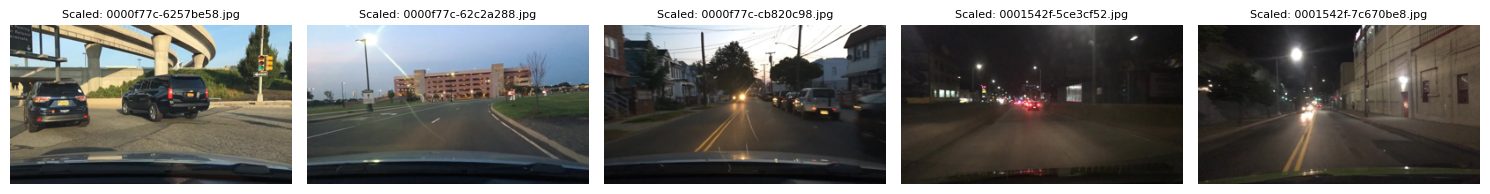

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
import os
scaled_images = []
plt.figure(figsize=(15, 10))
for i, row in df.head(5).iterrows():
    image_name = row['name']
    original_image_path = os.path.join(images_cache_path, image_name)

    if os.path.exists(original_image_path):
        img = Image.open(original_image_path)

        resized_img = img.resize((320, 180))
        scaled_images.append(resized_img)

        plt.subplot(1, 5, i + 1)
        plt.imshow(resized_img)
        plt.title(f"Scaled: {image_name}", fontsize=8)
        plt.axis('off')
    else:
        print(f"Original image not found: {original_image_path}")

plt.tight_layout()
plt.show()

# Análisis del dataset BDD100K: Detección de objetos en imágenes de conducción

## 1. Carga y Exploración del Dataset

En esta sección, cargamos el archivo de anotaciones del dataset BDD100K y realizamos una inspección inicial de su estructura.

In [30]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "train/annotations/bdd100k_labels_images_train.json"
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "marquis03/bdd100k",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'bdd100k' dataset.
First 5 records:                     name                                         attributes  \
0  0000f77c-6257be58.jpg  {'weather': 'clear', 'scene': 'city street', '...   
1  0000f77c-62c2a288.jpg  {'weather': 'clear', 'scene': 'highway', 'time...   
2  0000f77c-cb820c98.jpg  {'weather': 'clear', 'scene': 'residential', '...   
3  0001542f-5ce3cf52.jpg  {'weather': 'clear', 'scene': 'city street', '...   
4  0001542f-7c670be8.jpg  {'weather': 'clear', 'scene': 'highway', 'time...   

   timestamp                                             labels  
0      10000  [{'category': 'traffic light', 'attributes': {...  
1      10000  [{'category': 'traffic sign', 'attributes': {'...  
2      10000  [{'category': 'car', 'attributes': {'occluded'...  
3      10000  [{'category': 'traffic sign', 'attributes': {'...  
4      10000  [{'category': 'car', 'attributes': {'occluded'...  


### 2.1. Descarga del Dataset y Verificación de Archivos

Para asegurar que todas las imágenes y archivos de anotaciones estén disponibles localmente, descargamos el dataset completo y verificamos la presencia de los archivos clave.

In [31]:
import os
import kagglehub
dataset_root_path = kagglehub.dataset_download(
    "marquis03/bdd100k"
)

annotations_path = os.path.join(dataset_root_path, "train", "annotations")
print(os.listdir(annotations_path))

Using Colab cache for faster access to the 'bdd100k' dataset.
['bdd100k_labels_images_train.json']


In [32]:
dataset_root_path = kagglehub.dataset_download(
    "marquis03/bdd100k"
)

images_cache_path = os.path.join(dataset_root_path, "train", "images")
print(f"Dataset downloaded to: {dataset_root_path}")
print(f"Images are expected to be available at: {images_cache_path}")

Using Colab cache for faster access to the 'bdd100k' dataset.
Dataset downloaded to: /kaggle/input/bdd100k
Images are expected to be available at: /kaggle/input/bdd100k/train/images


## 2. Visualización de Imágenes de Muestra

Visualizamos algunas imágenes de muestra.

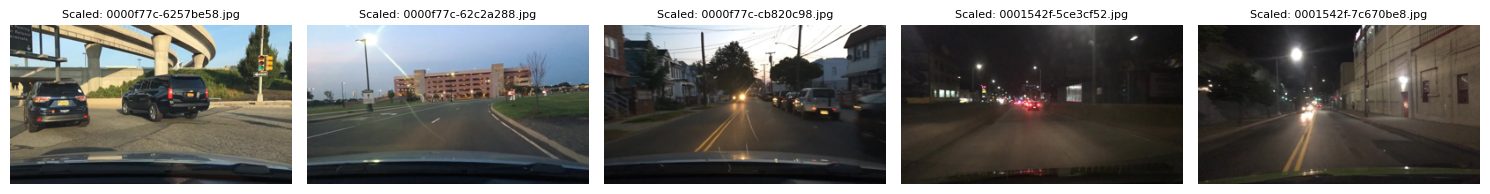

In [33]:
from PIL import Image
import matplotlib.pyplot as plt
import os
scaled_images = []
plt.figure(figsize=(15, 10))
for i, row in df.head(5).iterrows():
    image_name = row['name']

    original_image_path = os.path.join(images_cache_path, image_name)

    if os.path.exists(original_image_path):
        img = Image.open(original_image_path)

        resized_img = img.resize((320, 180))
        scaled_images.append(resized_img)

        plt.subplot(1, 5, i + 1)
        plt.imshow(resized_img)
        plt.title(f"Scaled: {image_name}", fontsize=8)
        plt.axis('off')
    else:
        print(f"Original image not found: {original_image_path}")

plt.tight_layout()
plt.show()

## 3. Filtrado del Dataset por Condiciones de Luz

El dataset BDD100K incluye atributos como la 'hora del día'. Filtraremos las imágenes para separar aquellas tomadas durante el día de las tomadas durante la noche.

In [34]:
df_night = df[df['attributes'].apply(lambda x: x.get('timeofday') == 'night')]
df_day = df[df['attributes'].apply(lambda x: x.get('timeofday') != 'night')]

print("First 5 records of df_day:")
display(df_day.head())

print("\nFirst 5 records of df_night:")
display(df_night.head())

First 5 records of df_day:


,name,attributes,timestamp,labels
0,0000f77c-6257be58.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'traffic light', 'attributes': {..."
1,0000f77c-62c2a288.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'traffic sign', 'attributes': {'..."
2,0000f77c-cb820c98.jpg,"{'weather': 'clear', 'scene': 'residential', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
7,00054602-3bf57337.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
8,00067cfb-5443fe39.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."



First 5 records of df_night:


,name,attributes,timestamp,labels
3,0001542f-5ce3cf52.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'traffic sign', 'attributes': {'..."
4,0001542f-7c670be8.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
5,0001542f-ec815219.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
6,0004974f-05e1c285.jpg,"{'weather': 'rainy', 'scene': 'highway', 'time...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
9,00067cfb-5adfaaa7.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'traffic sign', 'attributes': {'..."


## 4. Escalado de Imágenes y Guardado en Disco

Para futuras tareas de modelado, es necesario escalar y guardar todas las imágenes de manera persistente en disco. Creamos directorios separados para las imágenes escaladas de día y de noche.

In [35]:
import os

df_day_scaled = df_day.copy()
df_day_scaled['name'] = df_day_scaled['name'].apply(lambda x: os.path.join(output_dir, f"scaled_day_{x}"))

df_night_scaled = df_night.copy()
df_night_scaled['name'] = df_night_scaled['name'].apply(lambda x: os.path.join(output_dir, f"scaled_night_{x}"))
print("Updated df_day (scaled) head:")
display(df_day_scaled.head())
print("\nUpdated df_night (scaled) head:")
display(df_night_scaled.head())

Updated df_day (scaled) head:


,name,attributes,timestamp,labels
0,scaled_images/scaled_day_0000f77c-6257be58.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'traffic light', 'attributes': {..."
1,scaled_images/scaled_day_0000f77c-62c2a288.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'traffic sign', 'attributes': {'..."
2,scaled_images/scaled_day_0000f77c-cb820c98.jpg,"{'weather': 'clear', 'scene': 'residential', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
7,scaled_images/scaled_day_00054602-3bf57337.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
8,scaled_images/scaled_day_00067cfb-5443fe39.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."



Updated df_night (scaled) head:


,name,attributes,timestamp,labels
3,scaled_images/scaled_night_0001542f-5ce3cf52.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'traffic sign', 'attributes': {'..."
4,scaled_images/scaled_night_0001542f-7c670be8.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
5,scaled_images/scaled_night_0001542f-ec815219.jpg,"{'weather': 'clear', 'scene': 'city street', '...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
6,scaled_images/scaled_night_0004974f-05e1c285.jpg,"{'weather': 'rainy', 'scene': 'highway', 'time...",10000,"[{'category': 'car', 'attributes': {'occluded'..."
9,scaled_images/scaled_night_00067cfb-5adfaaa7.jpg,"{'weather': 'clear', 'scene': 'highway', 'time...",10000,"[{'category': 'traffic sign', 'attributes': {'..."


In [36]:
from PIL import Image
import os
import pandas as pd
output_dir = 'scaled_images'
original_images_path = images_cache_path
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory '{output_dir}' already exists.")
def save_scaled_images(dataframe, prefix):
    processed_count = 0
    for index, row in dataframe.iterrows():
        original_image_name = row['name']
        original_image_full_path = os.path.join(original_images_path, original_image_name)

        if os.path.exists(original_image_full_path):
            try:
                img = Image.open(original_image_full_path)
                resized_img = img.resize((320, 180)) # Scale to 320x180

                scaled_image_name = f"scaled_{prefix}_{original_image_name}"
                scaled_image_full_path = os.path.join(output_dir, scaled_image_name)

                resized_img.save(scaled_image_full_path)
                processed_count += 1
            except Exception as e:
                print(f"Error processing {original_image_name}: {e}")
        else:
            print(f"Original image not found: {original_image_full_path}")
    print(f"Saved {processed_count} scaled images for '{prefix}'.")

print("Processing day images...")
save_scaled_images(df_day, 'day')
print("Processing night images...")
save_scaled_images(df_night, 'night')

print("Image scaling and saving complete.")

Directory 'scaled_images' already exists.
Processing day images...


KeyboardInterrupt: 

In [ ]:
import os

output_dir = 'scaled_images'
if os.path.exists(output_dir):
    print(f"The directory '{output_dir}' exists.")
    files_in_dir = os.listdir(output_dir)
    if files_in_dir:
        print(f"It contains {len(files_in_dir)} files. Here are the first 5:\n{files_in_dir[:5]}")
    else:
        print(f"The directory '{output_dir}' is empty.")
else:
    print(f"The directory '{output_dir}' does not exist. It seems the scaled images were not saved to disk.")